<table style="background-color: transparent; width:100%">
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%" align="center"><font size="7" color="#6366F1"><b>Computación Cuántica</b></font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Temas Selectos de Ingeniería en Computación III</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Facultad de Ingeniería, UNAM | Semestre: 2027-1</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="6" color="#6366F1"><b>Práctica 4: Algoritmos Cuánticos II (Deutsch-Jozsa y Transformada de Hadamard)</b></font></td>
    </tr>
</table>

---
* **Alumna:** Karla Beatriz Rojas Chimal
* **No. de Cuenta:** 320048025
* **Carrera:** Ingeniería en Computación
* **Profesora Titular:** Naomi Itzel Reyes Granados
* **Asistente:** González Juárez Sebastián

---
### Contenido del Notebook

1. [Algoritmo de Deutsch-Jozsa](#1)
2. [Aplicación de $H^{\otimes 4}$ sobre $|15\rangle$](#2)
3. [Opcional: Algoritmo de Deutsch con PennyLane](#3)


### Declaración sobre el uso de Inteligencia Artificial (Instrucción C)
De acuerdo con los lineamientos de la práctica, declaro el uso de herramientas de inteligencia artificial en la elaboración de este notebook.

* **Herramienta empleada:** Antigravity (asistente de IA de programación de Google DeepMind).
* **Incisos en los que se utilizó:** Estructura general del notebook, código y redacción de las explicaciones de los Ejercicios 1, 2 y 3.
* **Razón de su uso:** Generar el borrador del notebook siguiendo el formato de las prácticas anteriores y ejecutarlo en el entorno `compu_cuantica` para obtener las salidas. El resultado fue revisado por mí antes de la entrega.
* **Prompt principal utilizado:** *"De la práctica 3 y 4 haz el documento correspondiente de _RojasChimal_KarlaBeatriz_PRACTICAENTREGAR ... guíate de los laboratorios 1 y 2 para el formato ... NO USES AERSIMULATOR ... usa el kernel/ambiente de python de compu_cuantica"* (se anexaron las instrucciones completas de la práctica).


In [1]:
# Instalo todo en silencio, directo en el kernel que estoy usando
%pip install qiskit pennylane matplotlib pylatexenc --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ==============================================================================
#  /\_/\
# ( o.o )   CONFIGURACIÓN INICIAL: LIBRERÍAS
#  > ^ <
# ==============================================================================
import itertools
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit.providers.basic_provider import BasicSimulator

# Mi simulador para esta práctica (ideal, sin ruido, corre en Python puro)
sim = BasicSimulator()
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


<a id="1"></a>
```
 /\_/\
( o.o )  ¡a trabajar!
 > ^ <
```

# 1. Algoritmo de Deutsch-Jozsa

Se considera la función

$$f(x_0,x_1,x_2,x_3)=x_0\oplus x_2 ,\qquad x_i\in\{0,1\}.$$

Se usan un registro cuántico `x` de 4 qubits (entrada), un registro cuántico `y` de 1 qubit (auxiliar) y un registro clásico `res` de 4 bits. El qubit $x_i$ corresponde a `x[i]`.

### 1.a) Construcción y comprobación del oráculo $U_f$
Como $f$ es la suma módulo 2 de dos bits, el oráculo $U_f|x\rangle|y\rangle=|x\rangle|y\oplus f(x)\rangle$ se construye con dos `CNOT` que tienen como objetivo a `y`:

$$y\oplus f(x)=y\oplus x_0\oplus x_2 \;\Rightarrow\; \text{CNOT}(x_0\to y),\ \text{CNOT}(x_2\to y).$$

Para comprobarlo se construye la tabla de verdad de $f$ y, para cada una de las 16 entradas, se prepara $|x\rangle|0\rangle$, se aplica el oráculo y se lee el valor de `y` con `Statevector`.

Circuito del oráculo Uf:


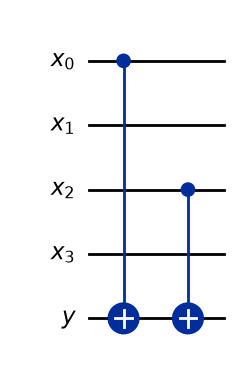

x0 x1 x2 x3   f(x)   y tras Uf (|x>|0>)    Correcto
0 0 0 0       0      0                     SI
0 0 0 1       0      0                     SI
0 0 1 0       1      1                     SI
0 0 1 1       1      1                     SI
0 1 0 0       0      0                     SI
0 1 0 1       0      0                     SI
0 1 1 0       1      1                     SI
0 1 1 1       1      1                     SI
1 0 0 0       1      1                     SI
1 0 0 1       1      1                     SI
1 0 1 0       0      0                     SI
1 0 1 1       0      0                     SI
1 1 0 0       1      1                     SI
1 1 0 1       1      1                     SI
1 1 1 0       0      0                     SI
1 1 1 1       0      0                     SI

¿El oráculo implementa correctamente f en las 16 entradas? True


In [3]:
# ==============================================================================
#  /\_/\
# ( o.o )   1. DEUTSCH-JOZSA: ORÁCULO Uf
#  > ^ <
# ==============================================================================
x = QuantumRegister(4, "x")
y = QuantumRegister(1, "y")
res = ClassicalRegister(4, "res")

def f(x0, x1, x2, x3):
    return x0 ^ x2

def construye_oraculo():
    """Oráculo Uf: |x>|y> -> |x>|y XOR (x0 XOR x2)>"""
    uf = QuantumCircuit(x, y, name="Uf")
    uf.cx(x[0], y[0])
    uf.cx(x[2], y[0])
    return uf

oraculo = construye_oraculo()
print("Circuito del oráculo Uf:")
display(oraculo.draw("mpl"))

# --- Armo la tabla de verdad y compruebo con Statevector que el oráculo sí hace lo que debe ---
print(f"{'x0 x1 x2 x3':<14}{'f(x)':<7}{'y tras Uf (|x>|0>)':<22}{'Correcto'}")
todo_ok = True
for bits in itertools.product([0, 1], repeat=4):          # bits = (x0, x1, x2, x3)
    prep = QuantumCircuit(x, y)
    for i, b in enumerate(bits):
        if b:
            prep.x(x[i])
    prep.compose(oraculo, inplace=True)
    sv = Statevector.from_instruction(prep)
    # Ojo: Qiskit es little-endian, así que q0..q3 son x0..x3 y q4 es y
    idx = int(np.argmax(np.abs(sv.data)))
    y_salida = (idx >> 4) & 1
    ok = (y_salida == f(*bits))
    todo_ok &= ok
    print(f"{' '.join(map(str, bits)):<14}{f(*bits):<7}{y_salida:<22}{'SI' if ok else 'NO'}")
print("\n¿El oráculo implementa correctamente f en las 16 entradas?", todo_ok)

```
  |\__/,|   (`\
  |_ _  |.--.) )
  ( T   )     /
 (((^_(((/(((_/
```

### 1.b) Implementación del algoritmo de Deutsch-Jozsa ($n=4$)
Pasos del circuito:

1. **Estado inicial:** $|0\rangle^{\otimes 4}|0\rangle$.
2. **Preparación del auxiliar:** `X` sobre `y` para obtener $|1\rangle$.
3. **Hadamard antes de $U_f$:** `H` sobre los 4 qubits de `x` y sobre `y`. El estado queda $\frac{1}{\sqrt{16}}\sum_x|x\rangle\otimes|-\rangle$.
4. **Oráculo $U_f$:** por *phase kickback* introduce la fase $(-1)^{f(x)}$ en cada término.
5. **Hadamard después de $U_f$:** `H` sobre los 4 qubits de `x`.
6. **Medición** únicamente de los 4 qubits de `x` en el registro clásico `res`.

Circuito completo de Deutsch-Jozsa (n = 4):


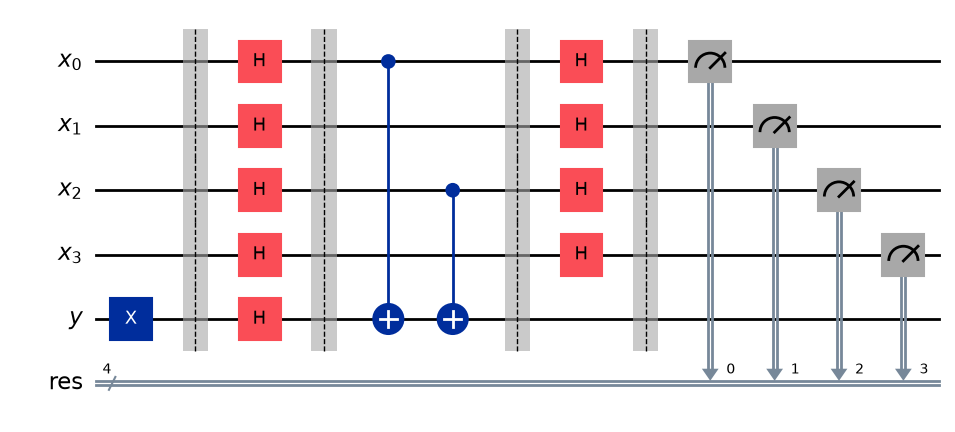

In [4]:
def deutsch_jozsa():
    qc = QuantumCircuit(x, y, res)
    # Primero dejo el qubit auxiliar y en |1>
    qc.x(y[0])
    qc.barrier()
    # Hadamard en todos antes del oráculo
    qc.h(x)
    qc.h(y[0])
    qc.barrier()
    # Aquí entra el oráculo Uf
    qc.compose(construye_oraculo(), inplace=True)
    qc.barrier()
    # Hadamard otra vez, pero solo en el registro x
    qc.h(x)
    qc.barrier()
    # Mido solo los 4 qubits de x (y no se toca)
    qc.measure(x, res)
    return qc

qc_dj = deutsch_jozsa()
print("Circuito completo de Deutsch-Jozsa (n = 4):")
display(qc_dj.draw("mpl"))

```
      /\_____/\
     /  o   o  \
    ( ==  ^  == )
     )         (
    (           )
   ( (  )   (  ) )
  (__(__)___(__)__)
```

### 1.c) Simulación e interpretación
Simulador: **`BasicSimulator`** de Qiskit con 1024 `shots`. Si $f$ fuera **constante**, el resultado de medir `x` sería siempre $0000$; si es **balanceada**, la probabilidad de medir $0000$ es cero.

Resultados de la medición del registro x (res = x3 x2 x1 x0): {'0101': 1024}


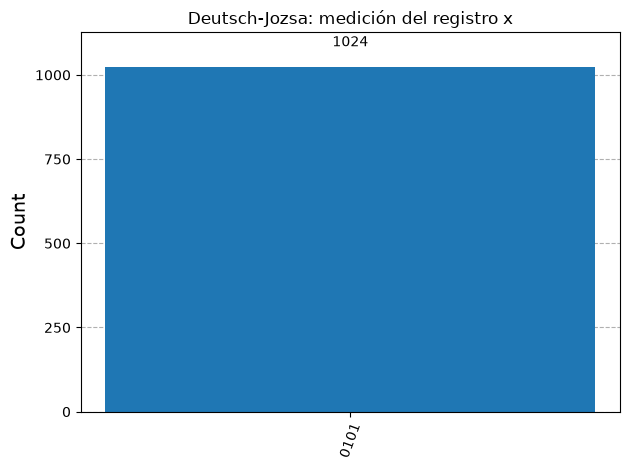

Resultado: la función es BALANCEADA (nunca se midió 0000).


In [5]:
SHOTS = 1024
conteos = sim.run(transpile(qc_dj, sim), shots=SHOTS).result().get_counts()
print("Resultados de la medición del registro x (res = x3 x2 x1 x0):", conteos)
display(plot_histogram(conteos, title="Deutsch-Jozsa: medición del registro x"))
plt.show()

if conteos.get("0000", 0) == SHOTS:
    print("Resultado: la función es CONSTANTE (se midió 0000 con probabilidad 1).")
elif conteos.get("0000", 0) == 0:
    print("Resultado: la función es BALANCEADA (nunca se midió 0000).")
else:
    print("Resultado no determinista (revisar el circuito).")

**Interpretación:** se mide siempre la cadena `0101` (en el orden $x_3x_2x_1x_0$), es decir, $x_0=1$, $x_2=1$ y $x_1=x_3=0$. Como **nunca** se obtiene $0000$, la función es **balanceada**, lo cual concuerda con $f=x_0\oplus x_2$ (vale 0 en 8 entradas y 1 en las otras 8). Además, la cadena medida revela los bits que participan en la suma módulo 2: $x_0$ y $x_2$.

<a id="2"></a>
```
  ∧,,,∧
 (  ̳• · • ̳)
 /    づ♡
```

# 2. Aplicación de $H^{\otimes 4}$ sobre $|15\rangle$

### 2.a) Preparación y desarrollo analítico
En la base computacional de cuatro qubits, $15=1111_2$, por lo tanto

$$|15\rangle=|1111\rangle=|1\rangle\otimes|1\rangle\otimes|1\rangle\otimes|1\rangle .$$

**Acción de $H$ sobre cada qubit:**

$$H|1\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}=|-\rangle .$$

**Producto tensorial resultante:**

$$H^{\otimes4}|1111\rangle=\left(\frac{|0\rangle-|1\rangle}{\sqrt2}\right)^{\otimes4}=\frac{1}{4}\left(|0\rangle-|1\rangle\right)\otimes\left(|0\rangle-|1\rangle\right)\otimes\left(|0\rangle-|1\rangle\right)\otimes\left(|0\rangle-|1\rangle\right).$$

**Expansión en la base computacional:** cada término $|x\rangle$ recibe el signo $(-1)^{\text{número de unos en }x}$, es decir, $H^{\otimes n}|y\rangle=\frac{1}{\sqrt{2^n}}\sum_x(-1)^{x\cdot y}|x\rangle$ con $y=1111$:

$$
\begin{aligned}
H^{\otimes4}|15\rangle=\frac14\big(&|0000\rangle-|0001\rangle-|0010\rangle+|0011\rangle-|0100\rangle+|0101\rangle+|0110\rangle-|0111\rangle\\
-&|1000\rangle+|1001\rangle+|1010\rangle-|1011\rangle+|1100\rangle-|1101\rangle-|1110\rangle+|1111\rangle\big).
\end{aligned}
$$

Las 16 amplitudes tienen magnitud $1/4$ y su signo depende de la paridad del número de unos.

```
   _._     _,-'""`-._
  (,-.`._,'(       |\`-/|
      `-.-' \ )-`( , o o)
            `-    \`_`"'-
```

### 2.b) Verificación mediante Qiskit
Se construye el circuito de 4 qubits que prepara $|15\rangle$ (compuerta `X` en cada qubit), aplica `H` en cada qubit y se compara el vector de estado con el resultado analítico.

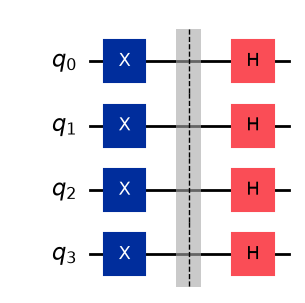

Vector de estado obtenido con Qiskit:


<IPython.core.display.Latex object>

|x>         Qiskit   Analítico
|0000>    0.2500      0.2500
|0001>   -0.2500     -0.2500
|0010>   -0.2500     -0.2500
|0011>    0.2500      0.2500
|0100>   -0.2500     -0.2500
|0101>    0.2500      0.2500
|0110>    0.2500      0.2500
|0111>   -0.2500     -0.2500
|1000>   -0.2500     -0.2500
|1001>    0.2500      0.2500
|1010>    0.2500      0.2500
|1011>   -0.2500     -0.2500
|1100>    0.2500      0.2500
|1101>   -0.2500     -0.2500
|1110>   -0.2500     -0.2500
|1111>    0.2500      0.2500

¿Coincide el vector de Qiskit con el resultado analítico? True


In [6]:
# ==============================================================================
#  /\_/\
# ( o.o )   2. H^{⊗4} SOBRE |15>
#  > ^ <
# ==============================================================================
qc_15 = QuantumCircuit(4)
qc_15.x(range(4))          # con X en todos paso de |0000> a |1111> = |15>
qc_15.barrier()
qc_15.h(range(4))          # y ahora sí, H en cada qubit (H^{⊗4})
display(qc_15.draw("mpl"))

sv_15 = Statevector.from_instruction(qc_15)
print("Vector de estado obtenido con Qiskit:")
display(sv_15.draw("latex"))

# Lo que salió a mano: cada |x> vale (-1)^{#unos} / 4
analitico = np.array([(-1) ** bin(k).count("1") / 4 for k in range(16)], dtype=complex)

print(f"{'|x>':<8}{'Qiskit':>10}{'Analítico':>12}")
for k in range(16):
    print(f"|{k:04b}>{sv_15.data[k].real:>10.4f}{analitico[k].real:>12.4f}")

print("\n¿Coincide el vector de Qiskit con el resultado analítico?", np.allclose(sv_15.data, analitico))

**Conclusión:** el vector de estado de Qiskit coincide en las 16 componentes con la expansión analítica, con amplitudes $\pm\frac14$ y signo dado por $(-1)^{\text{número de unos}}$. Qiskit ordena los qubits como $|q_3q_2q_1q_0\rangle$, pero al ser el estado simétrico en todos los qubits el resultado no depende del orden.

<a id="3"></a>
```
  /\_/\
 ( ^.^ )
  > ^ <  miau~
```

# 3. Opcional: Algoritmo de Deutsch con PennyLane

Se implementa el algoritmo de Deutsch para las cuatro funciones booleanas de una variable. La función general `construye_oraculo_pl(f0, f1)` crea el oráculo $U_f|x\rangle|y\rangle=|x\rangle|y\oplus f(x)\rangle$: para cada valor $x_0\in\{0,1\}$ con $f(x_0)=1$ aplica una `X` sobre `y` controlada por `x` con `control_values=[x_0]`.

Circuito de Deutsch: `X` sobre `y`, `H` sobre ambos, oráculo, `H` sobre `x` y medición de `x`. Si se mide $0$ la función es **constante**; si se mide $1$ es **balanceada**.

Constante: f(0)=0, f(1)=0


C:\Users\karla\miniconda3\envs\compu_cuantica\Lib\site-packages\pennylane\devices\device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


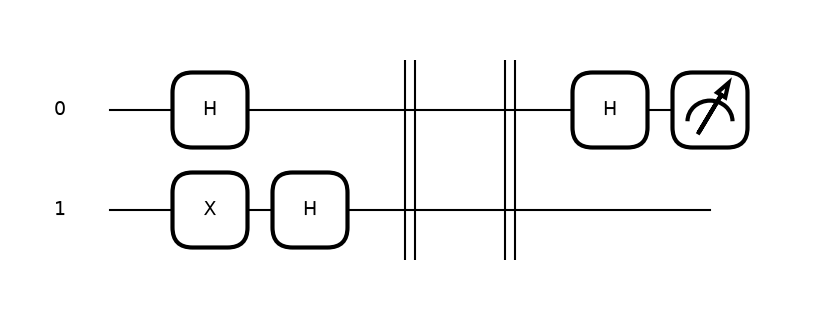

Resultado de la medición de x: {'0': 1024}
Se midió 0 -> la función es CONSTANTE
Constante: f(0)=1, f(1)=1


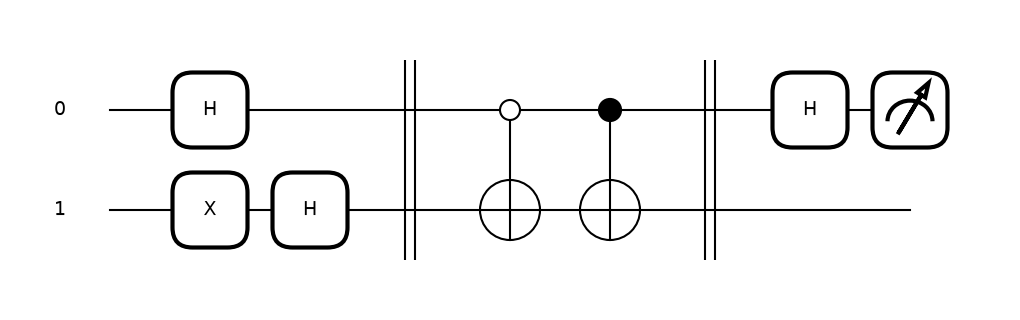

Resultado de la medición de x: {'0': 1024}
Se midió 0 -> la función es CONSTANTE
Balanceada: f(0)=0, f(1)=1


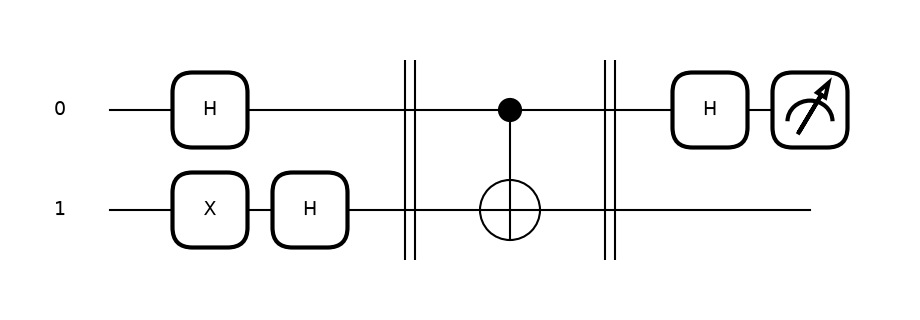

Resultado de la medición de x: {'1': 1024}
Se midió 1 -> la función es BALANCEADA
Balanceada: f(0)=1, f(1)=0


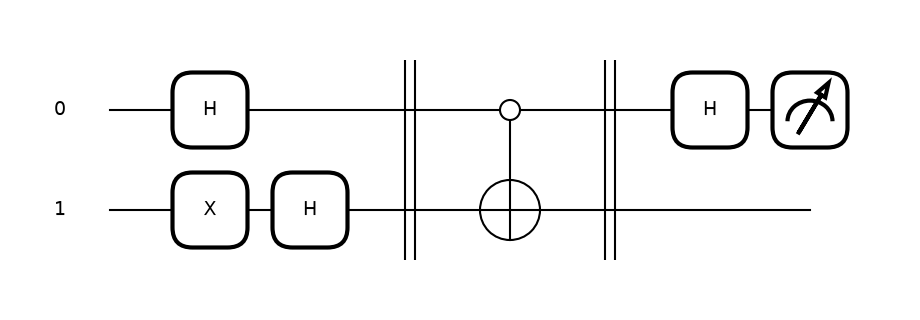

Resultado de la medición de x: {'1': 1024}
Se midió 1 -> la función es BALANCEADA


In [7]:
# ==============================================================================
#  /\_/\
# ( o.o )   3. ALGORITMO DE DEUTSCH CON PENNYLANE
#  > ^ <
# ==============================================================================
import pennylane as qml

dev = qml.device("default.qubit", wires=2, shots=1024)   # el wire 0 es x y el wire 1 es y

def construye_oraculo_pl(f0, f1):
    """Devuelve el oráculo Uf construido a partir de f(0)=f0 y f(1)=f1."""
    valores = {0: f0, 1: f1}
    def oraculo():
        for x_val, f_val in valores.items():
            if f_val == 1:
                # volteo y únicamente cuando x vale x_val
                qml.ctrl(qml.PauliX, control=0, control_values=[x_val])(wires=1)
    return oraculo

def crea_circuito_deutsch(f0, f1):
    oraculo = construye_oraculo_pl(f0, f1)

    @qml.qnode(dev)
    def circuito():
        qml.PauliX(wires=1)
        qml.Hadamard(wires=0)
        qml.Hadamard(wires=1)
        qml.Barrier(wires=[0, 1])
        oraculo()
        qml.Barrier(wires=[0, 1])
        qml.Hadamard(wires=0)
        return qml.counts(wires=0)
    return circuito

funciones = [
    ("Constante: f(0)=0, f(1)=0", 0, 0),
    ("Constante: f(0)=1, f(1)=1", 1, 1),
    ("Balanceada: f(0)=0, f(1)=1", 0, 1),
    ("Balanceada: f(0)=1, f(1)=0", 1, 0),
]

for nombre, f0, f1 in funciones:
    circuito = crea_circuito_deutsch(f0, f1)
    print("=" * 70)
    print(nombre)
    fig, ax = qml.draw_mpl(circuito)()
    plt.show()
    conteo = {str(k): int(v) for k, v in circuito().items()}
    medido = max(conteo, key=conteo.get)
    clasif = "CONSTANTE" if int(medido) == 0 else "BALANCEADA"
    print("Resultado de la medición de x:", conteo)
    print(f"Se midió {medido} -> la función es {clasif}")

**Conclusión:** para las dos funciones constantes se mide siempre $0$ y para las dos balanceadas siempre $1$, de modo que el algoritmo de Deutsch distingue ambos tipos con una sola evaluación del oráculo. Las cuatro funciones se construyeron con la misma función general `construye_oraculo_pl`.